In [8]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

In [9]:
# dist a reta
def distance_from_line(point, line):
    x0, y0 = point
    a, b, c = line  # reta no formato ax + by + c = 0
    return abs(a*x0 + b*y0 + c) / np.sqrt(a**2 + b**2)

#  reta (ax + by + c = 0) 
def line_from_points(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    a = y2 - y1
    b = x1 - x2
    c = (x2 * y1) - (x1 * y2)
    return a, b, c

def ransac(points, threshold, max_iterations):
    best_inliers = []
    best_line = None
    if len(points) < 2:
        raise ValueError("Não há pontos suficientes para executar o RANSAC.")
    for _ in range(max_iterations):
        # Escolher dois pontos aleatórios
        p1, p2 = random.sample(list(points), 2)

        # calc a reta 2 pontos
        line = line_from_points(p1, p2)

        #  inliers
        inliers = []
        for point in points:
            if distance_from_line(point, line) < threshold:
                inliers.append(point)

        # Atualizar best inliers
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_line = line

    return best_line, best_inliers


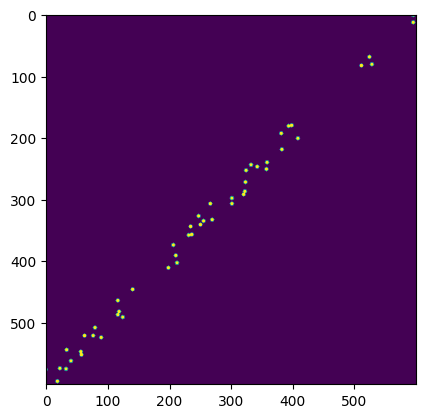

[(593, 0), (594, 0), (595, 0), (596, 0), (597, 0), (592, 1), (593, 1), (594, 1), (595, 1), (596, 1), (597, 1), (598, 1), (593, 2), (594, 2), (595, 2), (596, 2), (597, 2), (593, 3), (594, 3), (595, 3), (596, 3), (597, 3), (595, 4), (595, 10), (593, 11), (594, 11), (595, 11), (596, 11), (597, 11), (593, 12), (594, 12), (595, 12), (596, 12), (597, 12), (592, 13), (593, 13), (594, 13), (595, 13), (596, 13), (597, 13), (598, 13), (593, 14), (594, 14), (595, 14), (596, 14), (597, 14), (593, 15), (594, 15), (595, 15), (596, 15), (597, 15), (595, 16), (524, 66), (522, 67), (523, 67), (524, 67), (525, 67), (526, 67), (522, 68), (523, 68), (524, 68), (525, 68), (526, 68), (521, 69), (522, 69), (523, 69), (524, 69), (525, 69), (526, 69), (527, 69), (522, 70), (523, 70), (524, 70), (525, 70), (526, 70), (522, 71), (523, 71), (524, 71), (525, 71), (526, 71), (524, 72), (528, 78), (526, 79), (527, 79), (528, 79), (529, 79), (530, 79), (511, 80), (526, 80), (527, 80), (528, 80), (529, 80), (530, 80),

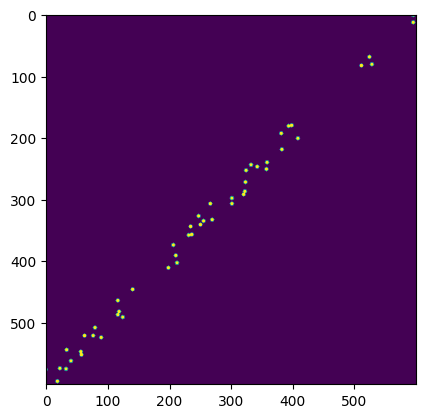

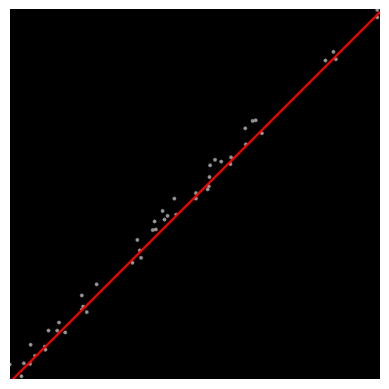

In [13]:
# Carregar a imagem
image = cv2.imread("./pontos_ransac.png", cv2.IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError("Erro ao carregar a imagem 'pontos_ransac.png'.")

plt.imshow(image)
plt.show()

# Aplicar threshold para isolar os pontos brancos 
_, binary_image = cv2.threshold(image, 100, 255, cv2.THRESH_BINARY)

plt.imshow(binary_image)

points = np.column_stack(np.where(binary_image == 255))  # Obtemos (y, x), então invertemos para (x, y)
points = [(x, y) for y, x in points]  # Converter para (x, y)

print(points)
plt.show()


# Parâmetros RANSAC
threshold = 5  # distância máxima 
max_iterations = 1000  # número máximo de iterações

if len(points) < 2:
    raise ValueError("[2]Não há pontos suficientes para executar o RANSAC.")

# Executar o RANSAC
best_line, inliers = ransac(points, threshold, max_iterations)

# Desenhar a melhor reta encontrada na imagem original
if best_line is not None:
    a, b, c = best_line
    # Encontrar dois pontos na borda da imagem para desenhar a linha
    height, width = image.shape
    if b != 0:
        x1, y1 = 0, int(-c / b)  # ponto na borda esquerda
        x2, y2 = width - 1, int(-(a * (width - 1) + c) / b)  # ponto na borda direita
    else:
        x1, y1 = int(-c / a), 0  # ponto na borda superior
        x2, y2 = int(-c / a), height - 1  # ponto na borda inferior

    # Desenhar a linha na imagem original
    output_img = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    cv2.line(output_img, (x1, y1), (x2, y2), (0, 0, 255), 2)

    # Mostrar a imagem original com a linha detectada
    plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
else:
    print("Nenhuma linha encontrada.")